In [27]:
# The python version I used is Python 3.13.9 

# Import pandas to read and clean the fraud detection data csv file.
# Using plain Python would require more manual code to  handle rows, colunms, missing values and data summaries.
# Pandas provides DataFrame and built-in functions to perform these operations efficiently.
# The alias 'pd' provides a shorter name when calling pandas functions repeatedly throughout the script.
# Import matplotlib.pyplot to create charts for comparing fraudulent and legitimate transactions.
# Plain Python does not provide built in plotting tools, 
# so matplotlib makes it easier to visualise transaction patterns and identify between both groups.
# The alias 'plt' shortens the long module name for repeated use throughout the script.


import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# Store the dataset filename in a variable for easy reuse when loading the fraud detection data.
file_name =  "fraud_detection_data.csv"

# Keep the loading code in one reusable function so the menu can run it
# whenever the user selects the load option.
def load_data(file_name):
    # Use try and except to handle cases where fraud detection CSV file cannot be found.
    # This prevents the script from stopping unexpectedly and displays a helpful message 
    # so the user can check the filename and folder location.
    try:
        # Store the loaded fraud detection data in 'df' so I can use it for cleaning, summaries and charts.
        df = pd.read_csv(file_name)
    except FileNotFoundError:
        print(f"{file_name} not found. Check the file name and the folder.")
    else:
        print("File has been found.")
        print(df.shape)
        print(df.head())
        return df

# Save the table in df so the other functions can work with it.
df = load_data("fraud_detection_data.csv")


File has been found.
(100, 6)
                         Transaction ID            Timestamp  Amount (USD)  \
0  00b226c6-408e-4e61-87ab-b3e36097234f  2022-12-03 05:37:04   8105.706085   
1  217dc884-8f0e-4c3b-b48d-4181e414e365  2023-03-15 14:38:59   5679.668616   
2  ffc30378-3f4a-4cdf-a2e5-6ab915790976  2024-04-08 05:03:11   8668.981575   
3  fd869a59-e5cc-4bea-8045-b1c5d15e3e16  2023-04-15 02:04:02   1816.610534   
4  4997b9c8-fe47-4d1d-8b1d-3d870b748758  2023-12-31 23:43:03   2953.946854   

                   Merchant           Location  Is Fraud  
0                Medina PLC     Freemanchester      True  
1           Estrada-Roberts     West Kevinfurt     False  
2  Shaw, Aguilar and Miller  Port Jenniferland     False  
3                 Mccoy Inc       Rebeccaburgh     False  
4  James, Terry and Miranda         Lake David     False  


In [29]:

# Prepare the data by fixing incorrect types and checking for problems before summarising and plotting
def clean_data(df):
    # Convert the Timestamp column to datetime for accurate time-based analysis.
    # Use errors="coerce" to prevent invalid dates from stopping the script.
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

    # Count missing timestamps after conversion to identify dates that couldn't be processed.
    unconverted_dates = df["Timestamp"].isnull().sum()

    # Display a message based on whether any timestamps are missing.
    if unconverted_dates == 0:
        print("All timestamps converted successfully.")
    else:
        print(f"{unconverted_dates} timestamps could not be converted.")

    # Convert Amount (USD) to numeric values for accurate summaries and charts.
    # Use errors="coerce" so invalid values become missing instead of stopping the script.
    df["Amount (USD)"] = pd.to_numeric(df["Amount (USD)"], errors="coerce")

    # Count missing Amount (USD) after conversion to identify amounts that could not be processed.
    unconverted_amount = df["Amount (USD)"].isnull().sum()

    # Display a message based on whether any amounts are missing, 
    # so the user knows if bad values were found, rather than assuming the clean-up worked.
    if unconverted_amount == 0:
        print("All Amount (USD) converted successfully.")
    else:
        print(f"{unconverted_amount} Amount (USD) values could not be converted.")

    # Check for duplicate transactions without removing them, since repeated 
    # transactions may be genuine and should be investigated before deciding to delete them.
    duplicate_rows = df.duplicated().sum()

    if duplicate_rows == 0:
        print("No duplicate transactions found.")
    else:
        print(f"{duplicate_rows} duplicate transactions found. Further investigation is required.")
    # Return the clean data so the other functions can use it.
    return df
# Keep df updated with the cleaned data so other functions use the latest version.
df = clean_data(df)


All timestamps converted successfully.
All Amount (USD) converted successfully.
No duplicate transactions found.


In [30]:
# Summarise the data so the menu can show the user useful information.
def summarise_data(df):
    # Gives the user a quick summary of the numerical data without reading every row.
    print("Amount statistics:")
    print(df.describe())
    # Check how common fraud is compared with normal transactions.
    print("Fraud count:")
    print(df["Is Fraud"].value_counts())
summarise_data(df)


Amount statistics:
                        Timestamp  Amount (USD)
count                         100    100.000000
mean   2023-11-30 19:07:25.180000   5237.181912
min           2022-11-19 17:51:26    276.883870
25%    2023-06-21 15:44:11.500000   2964.882980
50%           2023-11-06 15:06:04   5317.368543
75%    2024-06-20 06:30:10.500000   7994.533981
max           2024-11-13 09:05:47   9875.375601
std                           NaN   2879.897286
Fraud count:
Is Fraud
True     58
False    42
Name: count, dtype: int64


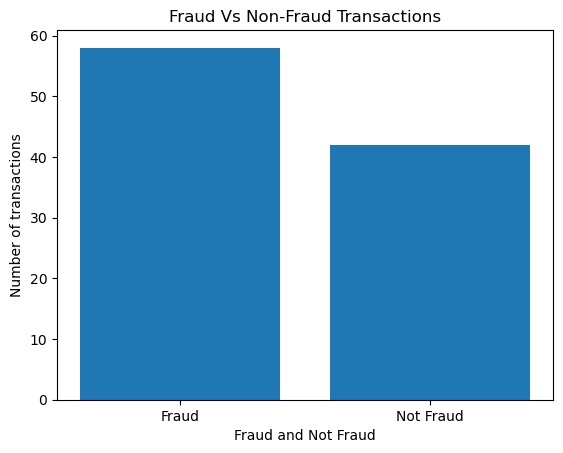

In [31]:
# Create a chart showing the number of fraud and non-fraud transactions when selected from the menu
def plot_fraud_counts(df):
    fraud_counts = df["Is Fraud"].value_counts()
    # Convert True and False into clear fraud labels so the user can easily understand the chart.
    plt.bar(fraud_counts.index.map({True: "Fraud", False: "Not Fraud"}), fraud_counts.values)
    plt.title("Fraud Vs Non-Fraud Transactions")
    plt.xlabel("Fraud and Not Fraud")
    plt.ylabel("Number of transactions")
    # Display the chart so the user can see it when the script runs.
    plt.show()
plot_fraud_counts(df)

In [32]:
# Keep the menu in one function so it can be displayed again whenever the user needs to make a choice.
def show_menu():
    print("1. Load the fraud detection data")
    print("2. Clean the fraud detection data")
    print("3. Summarise the fraud detection data")
    print("4. Visualise the fraud detection data")
    print("5. Exit")

In [ ]:
# Start with no data loaded so the program knows when the user has not selected a file yet.
df = None
# Keeps showing the menu until the user chooses to exit.
while True:
    show_menu()
    choice = input("Enter your choice (1-5): ")
    # Check if the user entered a valid menu option before processing their choice.
    if choice not in [ "1", "2", "3", "4", "5"]:
        print("Invalid choice. Please enter a number from 1 to 5.")
    # Check which option the user selected so the program knows what to do.
    elif choice == "1":
        df = load_data("fraud_detection_data.csv")
    elif choice == "5":
        # Stops the menu loop when the user chooses to exit.
        break
    elif df is None:
        print("Fraud detection data is empty. Please load the data first using option 1")
    elif choice == "2":
        df = clean_data(df) # Cleans the fraud detection data so it is ready for analysis.
    elif choice == "3":
        summarise_data(df) # Summarises the fraud detection data so the user can understand the key information.
    elif choice == "4":
        plot_fraud_counts(df) # Plot fraud counts so the user can easily compare fraudulent and non-fraudulent transactions.
    
    


1. Load the fraud detection data
2. Clean the fraud detection data
3. Summarise the fraud detection data
4. Visualise the fraud detection data
5. Exit
Invalid choice. Please enter a number from 1 to 5.
1. Load the fraud detection data
2. Clean the fraud detection data
3. Summarise the fraud detection data
4. Visualise the fraud detection data
5. Exit
Fraud detection data is empty. Please load the data first using option 1
1. Load the fraud detection data
2. Clean the fraud detection data
3. Summarise the fraud detection data
4. Visualise the fraud detection data
5. Exit
Fraud detection data is empty. Please load the data first using option 1
1. Load the fraud detection data
2. Clean the fraud detection data
3. Summarise the fraud detection data
4. Visualise the fraud detection data
5. Exit
